In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load Dataset

df = pd.read_csv("Position_Salaries.csv")

# Display first 5 records
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [3]:
print("Dataset Information\n")
print(df.info())

print("\nSummary Statistics\n")
print(df.describe())

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes
None

Summary Statistics

          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75%     7.75000   275000.000000
max    10.00000  1000000.000000


In [4]:
# Input Feature
X = df[['Level']]

# Target Variable
y = df['Salary']

print("Input Feature:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

Input Feature:
   Level
0      1
1      2
2      3
3      4
4      5

Target Variable:
0     45000
1     50000
2     60000
3     80000
4    110000
Name: Salary, dtype: int64


In [5]:
print(df.isnull().sum())

Position    0
Level       0
Salary      0
dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [8]:
model = LinearRegression()

model.fit(X_train_poly, y_train)

LinearRegression()

In [9]:
y_pred = model.predict(X_test_poly)

print("Predicted Salaries:")
print(y_pred)

Predicted Salaries:
[606335.60051157  84934.89129171]


In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("R2 Score :", r2)

Mean Absolute Error : 70635.24590164085
Mean Squared Error : 6263853282.860292
R2 Score : 0.8762695647830065


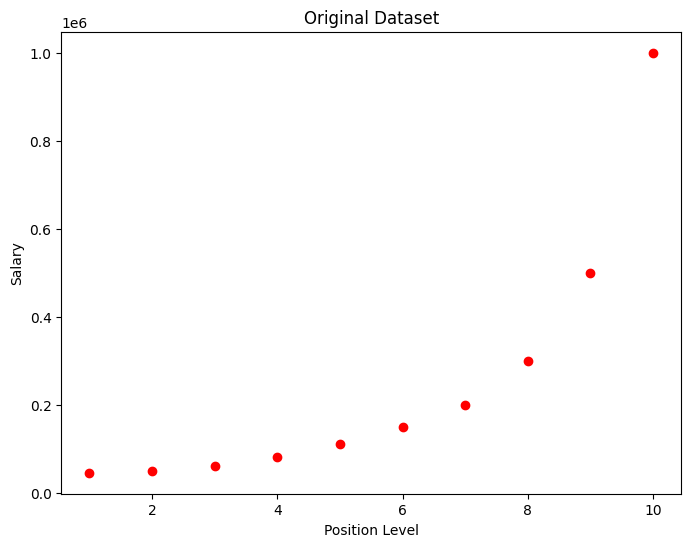

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(X, y, color='red')

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Original Dataset")

plt.show()

/tmp/ipykernel_876/4225415823.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X.values), max(X.values), 0.1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


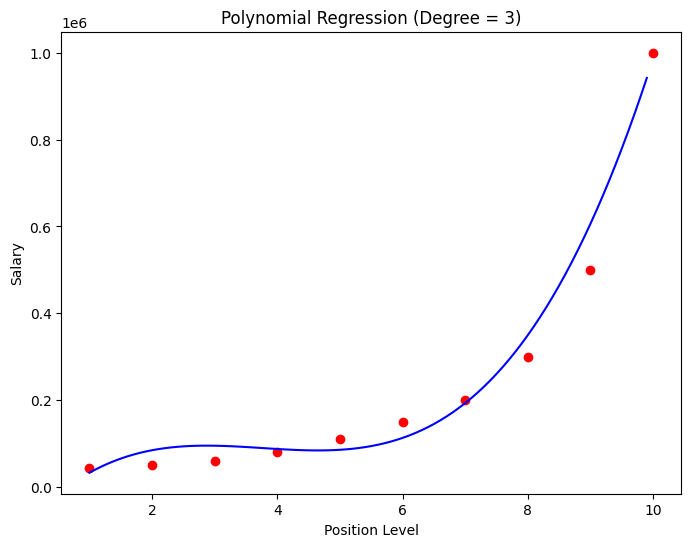

In [12]:
X_grid = np.arange(min(X.values), max(X.values), 0.1)
X_grid = X_grid.reshape(len(X_grid),1)

plt.figure(figsize=(8,6))

plt.scatter(X, y, color='red')

plt.plot(
    X_grid,
    model.predict(poly.transform(X_grid)),
    color='blue'
)

plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.title("Polynomial Regression (Degree = 3)")

plt.show()

In [13]:
level = 6.5

salary = model.predict(poly.transform([[level]]))

print("Predicted Salary for Level", level, "=", salary[0])

Predicted Salary for Level 6.5 = 145306.94600786245


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
